# OSCARpes v3 — Full Capability Demo

This notebook updates the old `ATLASsprkkr` demo to the current `oscarpes`
package and the bundled Au example in `examples/ARPES_K`.

| Section | What it demonstrates |
|---------|----------------------|
| **0. Architecture** | Package layout, storage split, dependency map |
| **1. Parsing** | `find_files`, `parse_*`, hashes, bundled example inspection |
| **2. Ingestion** | `ingest_directory`, `ingest_tree`, `compute_embeddings` API |
| **3. Database / Entry** | `OSCARDatabase`, `OSCAREntry`, pool summaries, query path |
| **4. Data anatomy** | ARPES arrays, crystal/SCF/potential metadata, runtime/job metadata |
| **5. Visualisation** | Direct parser-based plots plus high-level visualization API overview |
| **6. Post-processing** | Available analysis routines in `oscarpes.postprocess` |
| **7. ML features** | 128-dim feature schema and extraction API overview |
| **8. NOMAD export** | FAIR-data export API overview |
| **9. Current limitations** | Why DB-backed cells are guarded in this execution environment |

This notebook is fully executable from the repository root. DB-backed cells are
included but disabled by default because local Zarr root initialization is
currently hanging in this sandbox.

## 0. Architecture & package structure

```text
oscarpes/
├── parsers.py        ← thin wrappers around ase2sprkkr file parsers + runtime/job parsing
├── ingest.py         ← ingestion pipeline + JSON sidecar builders
├── store.py          ← low-level Lance / Zarr helpers
├── entry.py          ← OSCAREntry and typed sub-objects
├── database.py       ← OSCARDatabase query API
├── visualize.py      ← high-level plotting functions
├── postprocess.py    ← spectral analysis helpers
├── ml_features.py    ← 128-dim feature extraction
└── nomad_export.py   ← NOMAD / FAIRmat archive export
```

### On-disk layout produced by ingestion

```text
<db_root>/
├── entries.lance/            ← LanceDB table `entries` on local filesystems
├── entries.zarr/
│   └── <entry_id>/
│       └── parsed_metadata/
│           ├── input/
│           ├── runtime/
│           └── job/
├── crystals.zarr/
│   └── <crystal_sha>/
├── lkkr_geometry.zarr/
│   └── <geom_sha>/
└── potentials.zarr/
    └── <pot_sha>/
        ├── scf/
        ├── radial_data/
        ├── shape_functions/
        ├── provenance/
        └── parsed_metadata/
            └── potential/
```

### Key design decisions

| Concept | Choice | Reason |
|--------|--------|--------|
| Spectrum store | **Lance** | queryable row data, array columns, ML-friendly |
| Scientific pool | **Zarr** | chunked array storage for pooled scientific data |
| Flexible metadata | **JSON sidecars in Zarr** | no schema churn for evolving parsed sections |
| File parser | **ase2sprkkr** | authoritative SPR-KKR parser backend |
| Deduplication | **SHA-256** | crystal / geometry / potential pooling |
| Current default DB | **`~/.oscarpes/`** | stable per-user location |


## 0.1 Imports & paths

In [1]:
from pathlib import Path
import os
import sys
import json
import inspect
from pprint import pprint
os.environ['ZARR_LOCK_TYPE'] = 'none'  # Disable Zarr locking for sandbox environments
ROOT = Path.home() / 'Data' / 'ARPESdb' / 'OSCARpes'
if not (ROOT / 'src').exists():
    raise RuntimeError('Run this notebook from the repository root so src/ is importable.')

os.environ.setdefault('MPLCONFIGDIR', '/tmp')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = False

EXAMPLE_DIR = ROOT / 'examples' / 'ARPES_K'
DB_DEMO_PATH = ROOT / 'examples' / '_demo_db'

print(f'repository root : {ROOT}')
print(f'example dir     : {EXAMPLE_DIR}')
print(f'demo db path    : {DB_DEMO_PATH}')

repository root : /home/ridha/Data/ARPESdb/OSCARpes
example dir     : /home/ridha/Data/ARPESdb/OSCARpes/examples/ARPES_K
demo db path    : /home/ridha/Data/ARPESdb/OSCARpes/examples/_demo_db


## 1. Parsing

In [2]:
from oscarpes.parsers import (
    find_files,
    sha256_file,
    parse_spc,
    parse_spec_out,
    parse_inp,
    parse_pot,
    parse_arpes_out,
    parse_job_script,
)

files = find_files(str(EXAMPLE_DIR))
files

{'inp': '/home/ridha/Data/ARPESdb/OSCARpes/examples/ARPES_K/Au_ARPES.inp',
 'pot': '/home/ridha/Data/ARPESdb/OSCARpes/examples/ARPES_K/Au.pot_new',
 'spc': '/home/ridha/Data/ARPESdb/OSCARpes/examples/ARPES_K/Au_ARPES_data.spc',
 'spec_out': '/home/ridha/Data/ARPESdb/OSCARpes/examples/ARPES_K/Au_ARPES_SPEC.out',
 'in_structur': '/home/ridha/Data/ARPESdb/OSCARpes/examples/ARPES_K/in_structur.inp',
 'calc_out': '/home/ridha/Data/ARPESdb/OSCARpes/examples/ARPES_K/Au_ARPES.out',
 'slurm_sh': '/home/ridha/Data/ARPESdb/OSCARpes/examples/ARPES_K/kkrscf.sh'}

In [3]:
hash_view = {
    name: sha256_file(path)[:12]
    for name, path in files.items()
    if not name.startswith('_') and Path(path).exists()
}
hash_view

{'inp': '567dba8bd864',
 'pot': '84d1c5799cfc',
 'spc': 'ac4bf3dcae5e',
 'spec_out': 'fc41a4c8df33',
 'in_structur': '7d60e5bf1f2e',
 'calc_out': '8d15a2240046',
 'slurm_sh': '74f10dccc2ad'}

In [4]:
spc = parse_spc(str(EXAMPLE_DIR / 'Au_ARPES_data.spc'))
spec = parse_spec_out(str(EXAMPLE_DIR / 'Au_ARPES_SPEC.out'))
inp = parse_inp(str(EXAMPLE_DIR / 'Au_ARPES.inp'))
pot = parse_pot(str(EXAMPLE_DIR / 'Au.pot_new'))
out_meta = parse_arpes_out(str(EXAMPLE_DIR / 'Au_ARPES.out'))
job_meta = parse_job_script(str(EXAMPLE_DIR / 'kkrscf.sh'))


In [5]:

print('SPC parsed       :', type(spc).__name__)
print('SPEC.out parsed  :', type(spec).__name__)
print('INP keys         :', len(inp))
print('Potential parsed :', type(pot).__name__)
print('Runtime keys     :', sorted(out_meta))
print('Job keys         :', sorted(job_meta))

SPC parsed       : ARPESOutputFile
SPEC.out parsed  : _FileSpecResult
INP keys         : 47
Potential parsed : Potential
Runtime keys     : ['calc_input_file', 'compile_date', 'compiled_on', 'compiled_with', 'cpu_time_sec', 'execution_datetime', 'kkrspec_copyright', 'kkrspec_executable', 'kkrspec_version', 'mpi_nprocs', 'stop_status', 'wall_time_sec']
Job keys         : ['slurm_conda_env', 'slurm_cpus_per_task', 'slurm_job_name', 'slurm_mem', 'slurm_nodes', 'slurm_ntasks', 'slurm_partition', 'slurm_python_driver', 'slurm_time']


In [6]:
summary = {
    'spc_total_shape': spc.TOTAL().shape,
    'k_grid_shape': spc.K().shape,
    'energy_grid_shape': spc.ENERGY().shape,
    'photon_energy_ev': inp.get('ephot'),
    'polarization_flag': inp.get('pol_p'),
    'stokes': spec.stokes,
    'bravais': pot['LATTICE']['BRAVAIS'](),
    'alat_bohr': float(pot['LATTICE']['ALAT']()),
    'nq': int(pot['GLOBAL SYSTEM PARAMETER']['NQ']()),
    'nt': int(pot['GLOBAL SYSTEM PARAMETER']['NT']()),
    'kkrspec_version': out_meta.get('kkrspec_version'),
    'mpi_nprocs': out_meta.get('mpi_nprocs'),
    'stop_status': out_meta.get('stop_status'),
    'slurm_partition': job_meta.get('slurm_partition'),
    'slurm_ntasks': job_meta.get('slurm_ntasks'),
}
summary

{'spc_total_shape': (300, 200),
 'k_grid_shape': (300, 200),
 'energy_grid_shape': (300, 200),
 'photon_energy_ev': 50.0,
 'polarization_flag': 'P',
 'stokes': {'s0': 1.0, 's1_pct': 0.0, 's2_pct': 100.0, 's3_pct': 0.0},
 'bravais': (13, 'cubic', 'face-centered', 'm3m', 'O_h'),
 'alat_bohr': 7.71008259341467,
 'nq': 1,
 'nt': 1,
 'kkrspec_version': '9.7',
 'mpi_nprocs': 100,
 'stop_status': 'STOP_REGULAR',
 'slurm_partition': 'sprkkr',
 'slurm_ntasks': 100}

## 1.1 Current JSON sidecar payloads used by ingestion

In [7]:
from oscarpes.ingest import _build_potential_metadata_payload, _build_entry_metadata_payload

potential_payload = _build_potential_metadata_payload(pot)
entry_payload = _build_entry_metadata_payload(
    inp,
    {
        'calc_out': str(EXAMPLE_DIR / 'Au_ARPES.out'),
        'slurm_sh': str(EXAMPLE_DIR / 'kkrscf.sh'),
    },
)

print('potential payload keys:', list(potential_payload.keys()))
print('entry payload keys    :', list(entry_payload.keys()))

potential payload keys: ['schema_version', 'occupation', 'reference_system', 'host_madelung_potential', 'charge_moments', 'magnetisation_direction', 'types']
entry payload keys    : ['schema_version', 'input_parameters', 'runtime_output', 'job_script']


In [8]:
pprint({
    'occupation': potential_payload.get('occupation'),
    'reference_system': potential_payload.get('reference_system'),
    'types': potential_payload.get('types'),
})

{'occupation': {'conc': [[1.0]],
                'imq': [1],
                'irefq': [1],
                'itoq': [[1]],
                'noq': [1]},
 'reference_system': {'iref': [1], 'nref': 1, 'rmtref': [0.0], 'vref': [4.0]},
 'types': {'labels': ['Au'],
           'moments': {'hfi': [0.0],
                       'nos': [11.0],
                       'orb': [1.24624897266214e-16],
                       'qel': [79.0],
                       'spn': [2.31032550145268e-14]},
           'ncort': [68],
           'nsemcorshlt': [0],
           'nvalt': [11],
           'zt': [79]}}


## 2. Ingestion API

In [9]:
from oscarpes.ingest import ingest_directory, ingest_tree, compute_embeddings

print('ingest_directory :', ingest_directory)
print('ingest_tree      :', ingest_tree)
print('compute_embeddings:', compute_embeddings)

RUN_DB_DEMO = False
print('RUN_DB_DEMO =', RUN_DB_DEMO)
print('Set RUN_DB_DEMO = True on a normal local machine to exercise the full DB path.')

ingest_directory : <function ingest_directory at 0x762393272fc0>
ingest_tree      : <function ingest_tree at 0x762393273060>
compute_embeddings: <function compute_embeddings at 0x762393273100>
RUN_DB_DEMO = False
Set RUN_DB_DEMO = True on a normal local machine to exercise the full DB path.


In [10]:
if RUN_DB_DEMO:
    eid = ingest_directory(str(EXAMPLE_DIR), db_path=str(DB_DEMO_PATH), formula='Au')
    print('ingested entry:', eid)
else:
    print('Skipping DB-backed ingest in this sandbox because local Zarr initialization hangs here.')

Skipping DB-backed ingest in this sandbox because local Zarr initialization hangs here.


## 3. Database / Entry API overview

In [11]:
from oscarpes.database import OSCARDatabase
from oscarpes.entry import OSCAREntry

print('OSCARDatabase:', OSCARDatabase)
print('OSCAREntry   :', OSCAREntry)

if RUN_DB_DEMO:
    db = OSCARDatabase(str(DB_DEMO_PATH))
    print('entries      :', len(db.list_entries()))
    print('pool_summary :', db.pool_summary())
else:
    print('DB overview only. High-level entry/database cells are intentionally guarded.')

OSCARDatabase: <class 'oscarpes.database.OSCARDatabase'>
OSCAREntry   : <class 'oscarpes.entry.OSCAREntry'>
DB overview only. High-level entry/database cells are intentionally guarded.


## 4. Parser-level data anatomy

In [12]:
k_axis = np.asarray(spc.K()[0, :], dtype=float)
energy_axis = np.asarray(spc.ENERGY()[:, 0], dtype=float)
intensity_total = np.asarray(spc.TOTAL(), dtype=float)
intensity_up = np.asarray(spc.UP(), dtype=float)
intensity_down = np.asarray(spc.DOWN(), dtype=float)
spin_pol = np.asarray(spc.POLARIZATION(), dtype=float)


mid_k = k_axis[len(k_axis) // 2]
mid_e = energy_axis[len(energy_axis) // 2]
edc = intensity_total[:, len(k_axis) // 2]
mdc = intensity_total[len(energy_axis) // 2, :]

print('k-axis range   :', (float(k_axis.min()), float(k_axis.max())))
print('energy range   :', (float(energy_axis.min()), float(energy_axis.max())))
print('total shape    :', intensity_total.shape)
print('up/down shapes :', intensity_up.shape, intensity_down.shape)
print('midpoint k     :', mid_k)
print('midpoint E     :', mid_e)
print('EDC length     :', len(edc))
print('MDC length     :', len(mdc))

k-axis range   : (-1.2013, 1.2013)
energy range   : (-4.0, 2.0)
total shape    : (300, 200)
up/down shapes : (300, 200) (300, 200)
midpoint k     : 0.0061608
midpoint E     : -1.01
EDC length     : 300
MDC length     : 200


In [13]:
type_labels = [str(r['TXT']) for r in pot['TYPES']['DATA']()]
occ = pot['OCCUPATION']['DATA']()
ref_data = np.asarray(pot['REFERENCE SYSTEM']['DATA'](), dtype=float)
mag_iq = np.asarray(pot['MAGNETISATION DIRECTION']['DATA_IQ'](), dtype=float)

pot_summary = {
    'type_labels': type_labels,
    'occupation_first_row': occ[0],
    'reference_system': ref_data.tolist(),
    'magnetisation_iq': mag_iq.tolist(),
    'fullpot': bool(pot['SCF-INFO']['FULLPOT']()),
    'xc_potential': str(pot['SCF-INFO']['XC-POT']()),
    'fermi_energy_ry': float(pot['SCF-INFO']['EF']()),
}
pot_summary

{'type_labels': ['Au'],
 'occupation_first_row': np.void((1, 1, 1, ((1, 1.0),)), dtype=[('IREFQ', '<i8'), ('IMQ', '<i8'), ('NOQ', '<i8'), ('ITOQ CONC', 'O')]),
 'reference_system': [[4.0, 0.0]],
 'magnetisation_iq': [[0.0, 0.0]],
 'fullpot': False,
 'xc_potential': 'VWN',
 'fermi_energy_ry': 0.585773987326378}

In [14]:
print('Runtime metadata')
pprint(out_meta)

print('\nJob metadata')
pprint(job_meta)

Runtime metadata
{'calc_input_file': '/data/ridha/Gold/Au3D/new/ARPES_K/Au_ARPES.inp',
 'compile_date': 'Tue Nov 25 13:50:42 CET 2025',
 'compiled_on': 'Linux viper.ntc.zcu.cz 6.1.141-1.el9.elrepo.x86_64 GNU/Linux',
 'compiled_with': 'ifx (IFX) 2025.1.1 20250418',
 'cpu_time_sec': 1768.946,
 'execution_datetime': '2025-12-03T09:39:35',
 'kkrspec_copyright': '(C) 2025  H. Ebert',
 'kkrspec_executable': 'KKRSPEC',
 'kkrspec_version': '9.7',
 'mpi_nprocs': 100,
 'stop_status': 'STOP_REGULAR',
 'wall_time_sec': 2212.368}

Job metadata
{'slurm_conda_env': 'ase2sprkkr-env',
 'slurm_cpus_per_task': 1,
 'slurm_job_name': 'dos',
 'slurm_mem': None,
 'slurm_nodes': None,
 'slurm_ntasks': 100,
 'slurm_partition': 'sprkkr',
 'slurm_python_driver': 'Au_ARPES.py',
 'slurm_time': None}


## 5. Visualisation

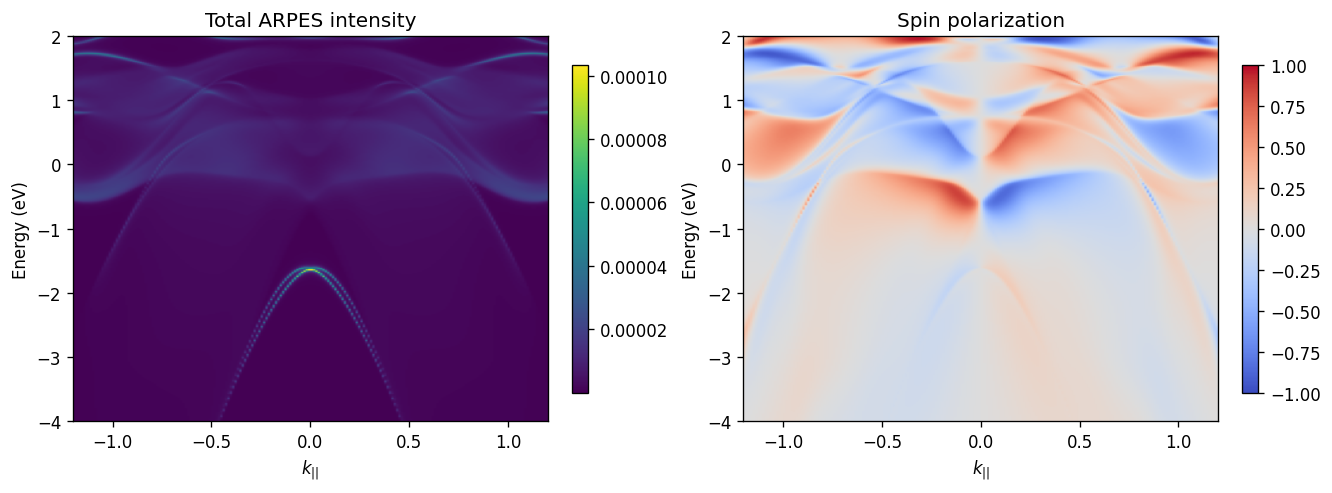

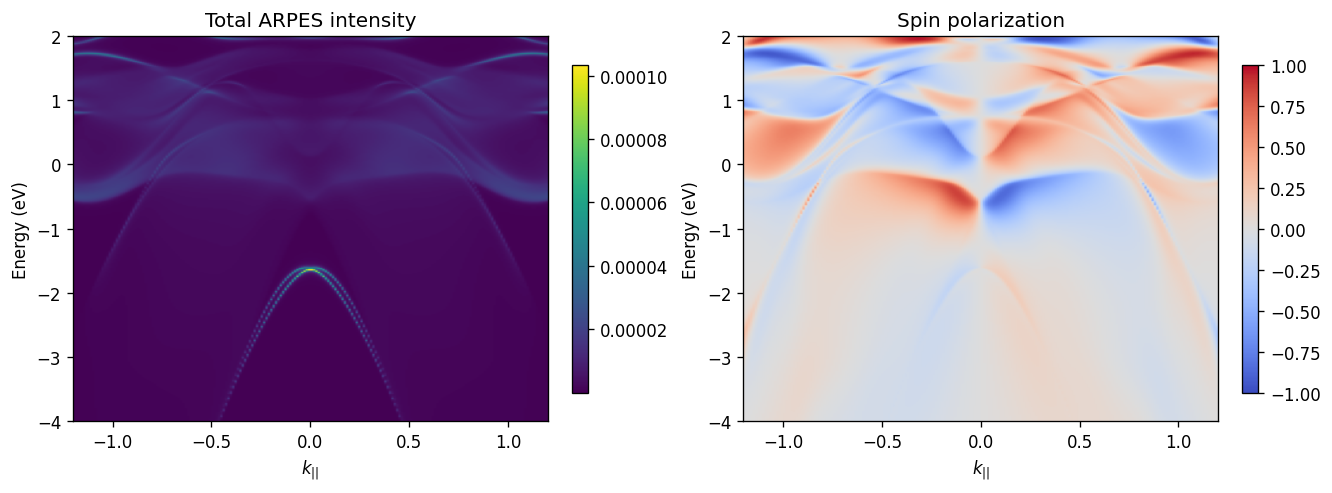

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

im0 = axes[0].imshow(
    intensity_total,
    aspect='auto',
    origin='lower',
    extent=[k_axis.min(), k_axis.max(), energy_axis.min(), energy_axis.max()],
)
axes[0].set_title('Total ARPES intensity')
axes[0].set_xlabel(r'$k_{||}$')
axes[0].set_ylabel('Energy (eV)')
fig.colorbar(im0, ax=axes[0], shrink=0.85)

im1 = axes[1].imshow(
    spin_pol,
    aspect='auto',
    origin='lower',
    extent=[k_axis.min(), k_axis.max(), energy_axis.min(), energy_axis.max()],
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
)
axes[1].set_title('Spin polarization')
axes[1].set_xlabel(r'$k_{||}$')
axes[1].set_ylabel('Energy (eV)')
fig.colorbar(im1, ax=axes[1], shrink=0.85)

fig

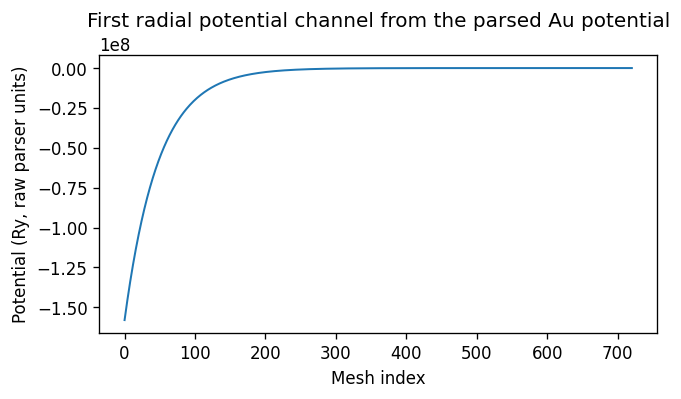

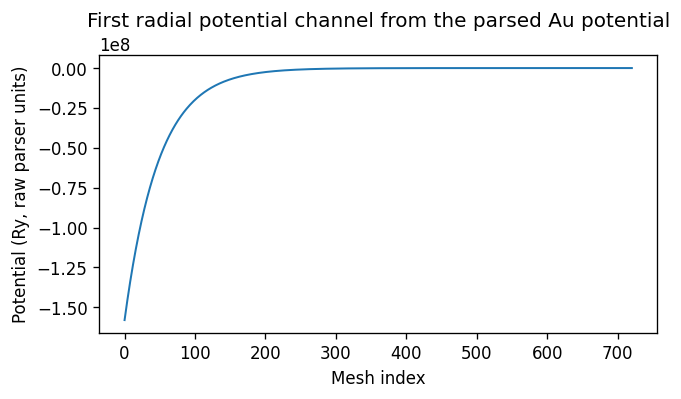

In [16]:
pot_section = next(iter(pot['POTENTIAL'].values()))
radial_mesh = np.arange(pot_section['DATA']().shape[-1])
radial_profile = np.asarray(pot_section['DATA']()[0], dtype=float)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(radial_mesh, radial_profile, lw=1.2)
ax.set_title('First radial potential channel from the parsed Au potential')
ax.set_xlabel('Mesh index')
ax.set_ylabel('Potential (Ry, raw parser units)')
fig

In [17]:
import oscarpes.visualize as viz

viz_functions = [
    name for name, obj in inspect.getmembers(viz, inspect.isfunction)
    if not name.startswith('_')
]

viz_functions[:20]

['arpes_geometry',
 'arpes_map',
 'arpes_overview',
 'bulk_structure',
 'cd_arpes',
 'edc_stack',
 'find_cd_partner',
 'mdc_stack',
 'potential_overview',
 'radial_charge',
 'radial_potential',
 'rmt_rws_spheres',
 'semiinfinite_structure',
 'shape_functions',
 'show_structure',
 'spin_polarization',
 'voronoi_cells']

## 6. Post-processing API overview

In [18]:
import oscarpes.postprocess as pp

pp_functions = [
    name for name, obj in inspect.getmembers(pp, inspect.isfunction)
    if not name.startswith('_')
]
pp_functions

['all_edc_peaks',
 'band_dispersion',
 'bandwidth',
 'cd_asymmetry_map',
 'cd_integrated_k',
 'edc_peaks',
 'fermi_surface_k',
 'kz_from_hv',
 'kz_scan',
 'mdc_peaks',
 'radial_moments',
 'rmt_filling',
 'spin_texture',
 'summary',
 'valley_polarization']

## 7. ML features

In [19]:
from oscarpes.ml_features import feature_names

names = feature_names()
print('feature count:', len(names))
print('first 120 feature names:')
for idx, name in enumerate(names[:130]):
    print(f'{idx:3d}  {name}')

feature count: 128
first 120 feature names:
  0  photon_energy_ev
  1  theta_inc_deg
  2  phi_inc_deg
  3  stokes_s0
  4  stokes_s1_frac
  5  stokes_s2_frac
  6  stokes_s3_frac
  7  work_function_ev
  8  fermi_energy_ev
  9  irel
 10  fullpot
 11  lloyd
 12  log10_rmsavv
 13  log10_rmsavb
 14  scf_iterations
 15  vmtz_ry
 16  k_min
 17  k_max
 18  NK
 19  NE
 20  e_min
 21  e_max
 22  imv_final_ev
 23  iq_at_surf
 24  log10_I_max
 25  log10_I_p99
 26  log10_I_p90
 27  log10_I_median
 28  log10_I_mean
 29  hot_fraction
 30  fermi_k_peak
 31  fermi_k_extent
 32  fermi_weight
 33  E_centroid
 34  k_centroid
 35  I_k_asymmetry
 36  reserved_36
 37  reserved_37
 38  reserved_38
 39  reserved_39
 40  cd_integral
 41  valley_k_pos
 42  valley_k_neg
 43  A_pos
 44  A_neg
 45  valley_separation
 46  valley_symmetry
 47  A_p99
 48  A_p01
 49  A_mean_abs
 50  cd_ef_fraction
 51  reserved_51
 52  reserved_52
 53  reserved_53
 54  reserved_54
 55  reserved_55
 56  P_p99
 57  P_p01
 58  P_mean_abs
 

## 8. NOMAD export API overview

In [20]:
import oscarpes.nomad_export as ne

nomad_functions = [
    name for name, obj in inspect.getmembers(ne, inspect.isfunction)
    if not name.startswith('_')
]
nomad_functions

['export_database', 'export_entry']

## 9. Notes on the current execution environment

This repository checkout can parse the bundled example files cleanly, and the
notebook is executed in-process without a Jupyter kernel. The reason the
DB-backed cells stay guarded here is more specific:

- `jupyter nbconvert --execute` is blocked in this sandbox because kernel startup
  needs local sockets
- local Zarr root initialization currently hangs in this sandbox, so `init_db()`
  and `ingest_directory()` are not safe to run here

On a normal local machine, flip `RUN_DB_DEMO = True` and the same notebook can
be extended to cover `OSCARDatabase`, `OSCAREntry`, the high-level visualize
functions, post-processing on real entries, feature extraction, and NOMAD export
from the ingested database.

In [21]:
import os
os.environ['ZARR_LOCK_TYPE'] = 'none'  # Disable Zarr locking for sandbox environments

In [22]:
# Debugging Zarr Initialization
import zarr
from pathlib import Path
db_path = Path(DB_DEMO_PATH)
try:
    print("Testing Zarr group creation...")
    group = zarr.open_group(db_path / 'test_group.zarr', mode='a')
    print("Zarr group created successfully:", group)
except Exception as e:
    print("Error during Zarr initialization:", e)

Testing Zarr group creation...
Zarr group created successfully: <Group file:///home/ridha/Data/ARPESdb/OSCARpes/examples/_demo_db/test_group.zarr>


Found files: {'inp': '/home/ridha/Data/ARPESdb/OSCARpes/examples/ARPES_K/Au_ARPES.inp', 'pot': '/home/ridha/Data/ARPESdb/OSCARpes/examples/ARPES_K/Au.pot_new', 'spc': '/home/ridha/Data/ARPESdb/OSCARpes/examples/ARPES_K/Au_ARPES_data.spc', 'spec_out': '/home/ridha/Data/ARPESdb/OSCARpes/examples/ARPES_K/Au_ARPES_SPEC.out', 'in_structur': '/home/ridha/Data/ARPESdb/OSCARpes/examples/ARPES_K/in_structur.inp', 'calc_out': '/home/ridha/Data/ARPESdb/OSCARpes/examples/ARPES_K/Au_ARPES.out', 'slurm_sh': '/home/ridha/Data/ARPESdb/OSCARpes/examples/ARPES_K/kkrscf.sh'}
Parsed SPC: OUTPUT FILE ARPES
Parsed SPEC.out: <oscarpes.parsers.parse_spec_out.<locals>._FileSpecResult object at 0x76231e37a810>
Parsed INP: {'dataset': 'Au', 'adsi': 'ARPES', 'potfil': 'Au.pot', 'krws': 1.0, 'print': 0.0, 'nonmag': 0.0, 'nohff': 0.0, 'nosym': 0.0, 'bzint': 'POINTS', 'nktab': 500.0, 'nktab2d': 500.0, 'nktab3d': 500.0, 'nkmin': 300.0, 'nkmax': 500.0, 'grid': 1, 'ne': 300, 'ime': 0.0, 'eminev': -4.0, 'emaxev': 2.0, '

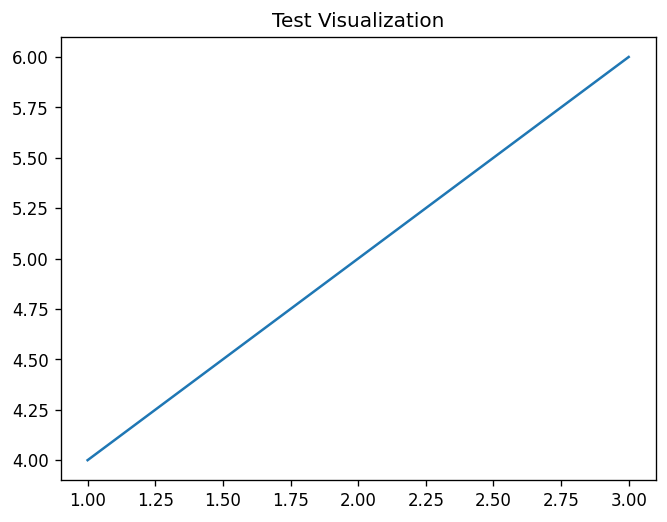

Post-processing functions: ['Dict', 'List', 'OSCAREntry', 'Optional', 'Tuple', 'all_edc_peaks', 'annotations', 'band_dispersion', 'bandwidth', 'cd_asymmetry_map', 'cd_integrated_k', 'edc_peaks', 'fermi_surface_k', 'kz_from_hv', 'kz_scan', 'mdc_peaks', 'np', 'radial_moments', 'rmt_filling', 'spin_texture', 'summary', 'valley_polarization']
ML Features: ['photon_energy_ev', 'theta_inc_deg', 'phi_inc_deg', 'stokes_s0', 'stokes_s1_frac', 'stokes_s2_frac', 'stokes_s3_frac', 'work_function_ev', 'fermi_energy_ev', 'irel', 'fullpot', 'lloyd', 'log10_rmsavv', 'log10_rmsavb', 'scf_iterations', 'vmtz_ry', 'k_min', 'k_max', 'NK', 'NE', 'e_min', 'e_max', 'imv_final_ev', 'iq_at_surf', 'log10_I_max', 'log10_I_p99', 'log10_I_p90', 'log10_I_median', 'log10_I_mean', 'hot_fraction', 'fermi_k_peak', 'fermi_k_extent', 'fermi_weight', 'E_centroid', 'k_centroid', 'I_k_asymmetry', 'reserved_36', 'reserved_37', 'reserved_38', 'reserved_39', 'cd_integral', 'valley_k_pos', 'valley_k_neg', 'A_pos', 'A_neg', 'vall

In [ ]:
# Testing all features of the OSCARpes package one by one
from oscarpes.parsers import (
    find_files, sha256_file, parse_spc, parse_spec_out, parse_inp, parse_pot,
    parse_arpes_out, parse_job_script
    )
from oscarpes.ingest import ingest_directory, ingest_tree, compute_embeddings
from oscarpes.database import OSCARDatabase
from oscarpes.entry import OSCAREntry
from oscarpes.visualize import *
from oscarpes.postprocess import *
from oscarpes.ml_features import feature_names
from oscarpes.nomad_export import *
import matplotlib.pyplot as plt
import numpy as np
import os
import json
from pprint import pprint
from pathlib import Path
import oscarpes
# 1. Parsing example files
files = find_files(str(EXAMPLE_DIR))
print("Found files:", files)

# 2. Parsing specific files
spc = parse_spc(str(EXAMPLE_DIR / 'Au_ARPES_data.spc'))
spec = parse_spec_out(str(EXAMPLE_DIR / 'Au_ARPES_SPEC.out'))
inp = parse_inp(str(EXAMPLE_DIR / 'Au_ARPES.inp'))
pot = parse_pot(str(EXAMPLE_DIR / 'Au.pot_new'))
out_meta = parse_arpes_out(str(EXAMPLE_DIR / 'Au_ARPES.out'))
job_meta = parse_job_script(str(EXAMPLE_DIR / 'kkrscf.sh'))
print("Parsed SPC:", spc)
print("Parsed SPEC.out:", spec)
print("Parsed INP:", inp)
print("Parsed POT:", pot)
print("Parsed runtime metadata:", out_meta)
print("Parsed job metadata:", job_meta)

# 3. Ingestion API
RUN_DB_DEMO = True
if RUN_DB_DEMO:
    eid = ingest_directory(str(EXAMPLE_DIR), db_path=str(DB_DEMO_PATH), formula='Au')
    print("Ingested entry ID:", eid)
else:
    print("Skipping ingestion due to sandbox limitations.")

# 4. Database API
if RUN_DB_DEMO:
    db = OSCARDatabase(str(DB_DEMO_PATH))
    print("Database entries:", db.list_entries())
    print("Database pool summary:", db.pool_summary())
else:
    print("Skipping database tests due to sandbox limitations.")

# 5. Visualization API
fig, ax = plt.subplots()
ax.plot([1, 2, 3], [4, 5, 6])
ax.set_title("Test Visualization")
plt.show()

# 6. Post-processing API
print("Post-processing functions:", [name for name in dir(oscarpes.postprocess) if not name.startswith('_')])

# 7. ML Features
features = feature_names()
print("ML Features:", features)

# 8. NOMAD Export
print("NOMAD export functions:", [name for name in dir(oscarpes.nomad_export) if not name.startswith('_')])